# EmotionFlow: Reinforcement Learning-Driven LSTM Networks for Emotion Regulation

# 1. Introduction:

## What is Emotion Regulation?
Emotion regulation refers to the brain’s ability to control, modify, and adapt emotional responses to stimuli based on context and goals. This involves a variety of cognitive processes that help maintain psychological balance and social function. Emotion regulation plays an essential role in managing both positive and negative emotions, ensuring appropriate responses to the environment.

## Emotion Regulation Networks in the Brain and Cognitive Control:

### Brain Areas Involved:

1. Prefrontal Cortex (PFC): Controls higher cognitive functions like decision-making and emotional control.
2. Anterior Cingulate Cortex (ACC): Regulates emotional reactions and links the emotional center of the brain (amygdala) with higher cognitive functions in the prefrontal cortex.
3. Amygdala: Associated with emotional processing, especially fear and threat responses.
4. Insula: Plays a role in processing self-awareness and emotional responses.

![Brain](JPBS_1672_Fig1.jpg.png)

### Cognitive Control: 

Cognitive control refers to the mental processes that allow us to control our emotions in order to achieve goals. It is a skill that's crucial in social interactions, stressful situations, or environments requiring self-discipline.

## Importance:
- Supports mental health and social functioning.

- Disruptions in emotion regulation are linked to mental health disorders such as anxiety, depression, and PTSD (Post-traumatic stress disorder).

# 2. AI Counterpart: Reinforcement Learning with Affective States

In the AI context, emotion regulation can be represented in terms of Reinforcement Learning (RL) with affective states, where an agent learns to act within its environment through reward and affective feedback.

## What is Reinforcement Learning?
Reinforcement learning is a subfield of machine learning in which an agent improves through interaction with its environment by receiving feedback through rewards and punishments and learning how to maximize their actions to generate maximum cumulative reward.

## Modelling Emotion Regulation in AI:
- Affective States: In reinforcement learning, an emotional state (frustration, satisfaction, stress) can be included as a part of state representation for the agent.

- Sentiment-Aware AI: Sentiment analysis can be used by AI models to modify their actions based on users' affective signals, adapting to respond in kind.

- Affective Computing: Deals with the detection and reaction to feelings in people using sensors or data analysis methods so that the AI can "feel" or "sense" emotion when interacting.

- Deep Reinforcement Learning with Emotions: An example of an agent learning to alter behavior dependent on its internal emotional states like fear, pleasure, or frustration very much like human emotion-based regulation.

## Mechanisms:
- Emotion as a Signal: Emotions are viewed as signals that regulate decision-making in such a way that the agent can prevent undesirable consequences or strive towards positive ones based upon experience.

- Adaptive Learning: Similar to human emotional regulation, the AI modifies its strategy based on the effect of its actions on its internal emotional state.

# 3. Implementation:

## 1. Install and Import Libraries
First, we install and import all necessary libraries for deep learning, reinforcement learning, and plotting.

In [168]:
# Install required libraries
!pip install torch numpy matplotlib gym transformers textblob seaborn

# Import libraries
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from textblob import TextBlob

# Set seeds for reproducibility
np.random.seed(0)
torch.manual_seed(0)

# Set plotting style
sns.set_theme(style="whitegrid")

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


# 2. Basic Emotion Regulation

## 2.1. Define Emotion Memory (LSTM) and Basic Emotion Regulation Agent

We create an LSTM-based emotional memory and a basic RL agent that uses it to regulate emotions.

## LSTM (Long Short-Term Memory)

LSTM networks are a type of Recurrent Neural Network (RNN) that work very well to learn from sequence data, i.e., time series, sentences, or sound signals.

### What's special about LSTMs:

- Memory Cells: LSTMs consist of memory cells that have the ability to hold information through many time steps.

### Gating Mechanisms:
- Input Gate: Regulates how much new information flows into the memory.
- Forget Gate: Determines what to forget from the past.
- Output Gate: Controls the amount of the memory to draw on in computing the current output.

This architecture enables LSTMs to learn long-distance dependencies and prevent vanishing gradients, which afflict typical RNNs. In emotional modeling, this equates to the LSTM remembering emotional cues several steps in the past—necessary to track slow emotional transitions in a conversation or narrative.

## Emotion + Memory + LSTM

Together, LSTM networks are effective emotion modeling tools:

- They can read emotional input serially (e.g., lines in a conversation).
- They retain emotional state from one step to the next—useful in tracking the development of emotions.

In [172]:
# Define Emotion Memory using an LSTM model
class EmotionMemoryLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(EmotionMemoryLSTM, self).__init__()
        
        # LSTM layer to process sequences of emotional states over time
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        
        # Fully connected layer to produce Q-values (or logits) from LSTM output
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # x shape: (batch_size, seq_len, input_dim)
        
        # Pass input through LSTM, ignore hidden state output for now
        lstm_out, _ = self.lstm(x)
        
        # Extract the last hidden state from the LSTM output
        last_hidden = lstm_out[:, -1, :]  # Shape: (batch_size, hidden_dim)
        
        # Pass it through a fully connected layer to get output (e.g., Q-values for actions)
        output = self.fc(last_hidden)     # Shape: (batch_size, output_dim)
        return output


# Define the Reinforcement Learning Agent that uses the LSTM-based memory
class BasicEmotionRegulationAgent:
    def __init__(self, state_dim, action_dim, memory_dim=32, lr=1e-3):
        # Initialize the LSTM-based memory network
        self.memory = EmotionMemoryLSTM(state_dim, memory_dim, action_dim)
        
        # Set up the optimizer (Adam) for learning
        self.optimizer = optim.Adam(self.memory.parameters(), lr=lr)
        
        # Use Mean Squared Error for loss calculation between predicted and target Q-values
        self.loss_fn = nn.MSELoss()
        
        # Save the number of possible actions
        self.action_dim = action_dim

    def select_action(self, state_seq):
        # Inference mode (no gradient calculation)
        with torch.no_grad():
            # Predict Q-values for each action given the input sequence
            q_values = self.memory(state_seq.unsqueeze(0))  # Add batch dimension
            
            # Choose the action with the highest Q-value (greedy policy)
            action = torch.argmax(q_values).item()
        return action

    def train(self, state_seq, target_q):
        # Forward pass: predict Q-values for the given sequence
        q_values = self.memory(state_seq.unsqueeze(0))  # Shape: (1, action_dim)
        
        # Compute loss between predicted Q-values and target Q-values
        loss = self.loss_fn(q_values, target_q.unsqueeze(0))  # Ensure matching shapes
        
        # Backward pass and optimization
        self.optimizer.zero_grad()  # Reset gradients
        loss.backward()            # Compute gradients
        self.optimizer.step()      # Update model weights


## 2.2. Create Basic Emotion Environment

The environment simulates basic emotions (happy, neutral, sad) and rewards the agent based on its emotional actions.

In [175]:
# Define a simple environment that simulates emotional states and how the agent interacts with them
class BasicEmotionEnvironment:
    def __init__(self):
        # Define three possible emotional states
        self.emotions = ['happy', 'neutral', 'sad']
        
        # Map each emotion to a one-hot encoded vector representation
        self.state_to_vec = {
            'happy': np.array([1, 0, 0]),
            'neutral': np.array([0, 1, 0]),
            'sad': np.array([0, 0, 1])
        }
        
        # Randomly initialize the current emotional state
        self.current_emotion = random.choice(self.emotions)

    def step(self, action):
        """
        Simulates the agent taking an action to regulate emotion.
        Returns:
        - next_state (one-hot encoded vector)
        - reward (based on whether the action matches the emotional need)
        - done (always False in this simple case)
        """
        reward = 0
        done = False  # The environment never ends in this version

        # Define the reward system based on current emotion and selected action
        if action == 0:  # Action: stay calm
            reward = 1 if self.current_emotion == 'neutral' else -1
        elif action == 1:  # Action: cheer up
            reward = 1 if self.current_emotion == 'sad' else -1
        elif action == 2:  # Action: stabilize happiness
            reward = 1 if self.current_emotion == 'happy' else -1

        # Transition to a new random emotional state (non-deterministic)
        self.current_emotion = random.choice(self.emotions)

        # Return new state (as vector), reward, and done flag
        return self.state_to_vec[self.current_emotion], reward, done

    def reset(self):
        """
        Resets the environment to a new random emotional state.
        Returns the state as a one-hot encoded vector.
        """
        self.current_emotion = random.choice(self.emotions)
        return self.state_to_vec[self.current_emotion]

## 2.3. Train Basic Emotion Regulation Agent

Now we train the basic agent using the environment and plot the reward and emotion trend over time.

In [178]:
# Initialize the environment and agent
basic_env = BasicEmotionEnvironment()
basic_agent = BasicEmotionRegulationAgent(state_dim=3, action_dim=3)  # 3 emotions, 3 possible actions

num_episodes = 300   # Number of training episodes
gamma = 0.9           # Discount factor for future rewards

# Containers to track training progress
emotion_trend_basic, action_trend, reward_trend = [], [], []

# Start training loop
for episode in range(num_episodes):
    state_seq = []                         # Holds the recent sequence of emotion states (for LSTM input)
    state = basic_env.reset()              # Reset environment at start of episode
    total_reward = 0                       # Accumulate total reward per episode

    for t in range(10):                    # Run for 10 time steps per episode
        # Add current state to the sequence (convert to tensor)
        state_seq.append(torch.tensor(state, dtype=torch.float32))

        # Keep only the last 5 states for LSTM memory window
        if len(state_seq) > 5:
            state_seq = state_seq[-5:]

        # Stack sequence into a tensor input (shape: seq_len x state_dim)
        state_seq_tensor = torch.stack(state_seq)

        # Agent selects action based on current emotional sequence
        action = basic_agent.select_action(state_seq_tensor)

        # Apply action in environment and get feedback
        next_state, reward, done = basic_env.step(action)

        # Accumulate reward for this episode
        total_reward += reward

        # Log emotional state, action taken, and reward received
        emotion_trend_basic.append(np.argmax(state))  # Convert one-hot vector to emotion index
        action_trend.append(action)
        reward_trend.append(reward)

        # Prepare next input sequence by adding the new state
        next_state_seq = state_seq + [torch.tensor(next_state, dtype=torch.float32)]
        if len(next_state_seq) > 5:
            next_state_seq = next_state_seq[-5:]
        next_state_seq_tensor = torch.stack(next_state_seq)

        # Estimate max future reward using target Q-values (without gradient update)
        with torch.no_grad():
            next_q = basic_agent.memory(next_state_seq_tensor.unsqueeze(0))  # shape: (1, action_dim)
            max_next_q = torch.max(next_q).item()

        # Create the target Q-value: reward + discounted future reward
        target_q = torch.zeros(basic_agent.action_dim)  # All-zero target Q initially
        target_q[action] = reward + gamma * max_next_q  # Update only the taken action's Q-value

        # Train the agent’s LSTM-Q network on the sequence and target
        basic_agent.train(state_seq_tensor, target_q)

        # Move to the next state
        state = next_state

    # Print total reward every 50 episodes to track progress
    if (episode + 1) % 50 == 0:
        print(f"[Basic] Episode {episode + 1}, Total Reward: {total_reward}")


[Basic] Episode 50, Total Reward: 10
[Basic] Episode 100, Total Reward: 10
[Basic] Episode 150, Total Reward: 10
[Basic] Episode 200, Total Reward: 10
[Basic] Episode 250, Total Reward: 10
[Basic] Episode 300, Total Reward: 10


The total reward is the sum of rewards the agent receives during the episode, which reflects how effectively it regulates emotions and interacts with the environment.

## 2.4. Plotting Results of Basic Agent
Visualizing the smoothed reward and emotional trend during the training.

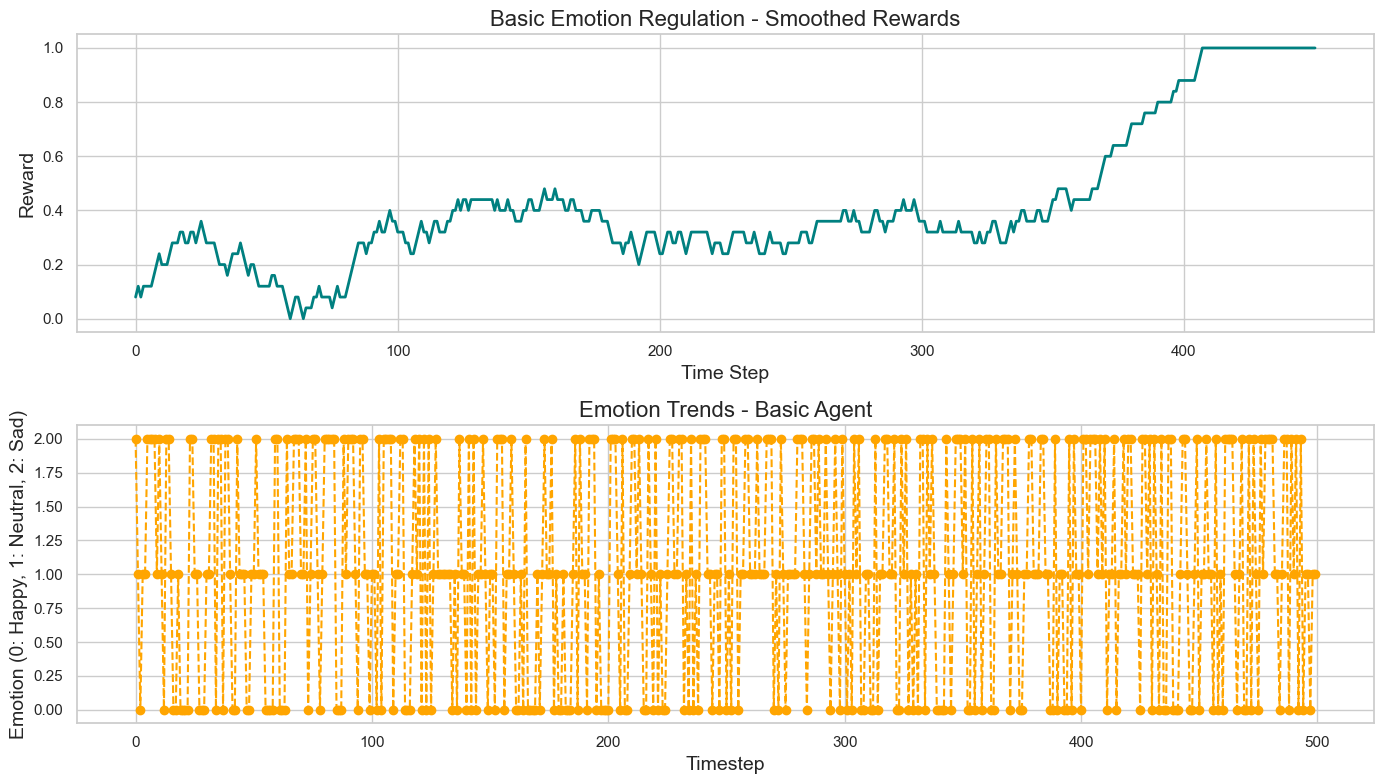

In [182]:
# Convert reward trend list to NumPy array for efficient processing
reward_trend = np.array(reward_trend)

# Limit both reward and emotion trends to the first 500 timesteps for clearer visualization
reward_trend = reward_trend[:500]
emotion_trend_basic = emotion_trend_basic[:500]

# Smooth the reward trend using a moving average with a window size of 50
# This helps reduce noise and visualize the learning trend better
smoothed_rewards = np.convolve(reward_trend, np.ones(50) / 50, mode='valid')

# Create a new figure with two vertically stacked subplots
plt.figure(figsize=(14, 8))

# -------------------- Subplot 1: Smoothed Reward Trend --------------------
plt.subplot(2, 1, 1)  # First subplot in a 2-row layout
plt.plot(smoothed_rewards, color='teal', linewidth=2)  # Plot smoothed reward signal
plt.title('Basic Emotion Regulation - Smoothed Rewards', fontsize=16)  # Plot title
plt.xlabel('Time Step', fontsize=14)  # X-axis label
plt.ylabel('Reward', fontsize=14)  # Y-axis label
plt.grid(True)  # Add grid for better readability

# -------------------- Subplot 2: Emotion Trend --------------------
plt.subplot(2, 1, 2)  # Second subplot
plt.plot(emotion_trend_basic, color='orange', linestyle='--', marker='o')  # Plot emotion labels over time
plt.title('Emotion Trends - Basic Agent', fontsize=16)  # Title for second plot
plt.xlabel('Timestep', fontsize=14)  # X-axis label
plt.ylabel('Emotion (0: Happy, 1: Neutral, 2: Sad)', fontsize=14)  # Y-axis for emotion class index
plt.grid(True)  # Grid for clarity

# Automatically adjust spacing between plots
plt.tight_layout()

# Display the final combined plot
plt.show()

# 3. Advanced Emotion Regulation

## BERT-Based Emotion Model

A BERT-Based Emotion Model uses the Bidirectional Encoder Representations from Transformers (BERT) architecture to detect and classify emotions from text. Unlike LSTMs, which process sequences step by step, BERT processes the entire sentence at once using transformer-based attention, allowing it to capture deep, contextualized meaning of words based on their surroundings.

## Why BERT for Emotion?

- Bidirectional context: Understands emotional tone better by looking at full context.
- Pretrained knowledge: Already knows a lot about language nuances.
- Fine-tuning efficiency: Performs well with relatively small datasets.

## 3.1. Load BERT-Based Emotion Model

For advanced regulation, we use a pretrained BERT model to detect complex emotions from sentences.

### Emotion	Vector Representation

Joy	       - [1, 0, 0, 0, 0]

Sadness	   - [0, 1, 0, 0, 0]

Anger	   - [0, 0, 1, 0, 0]

Fear	   - [0, 0, 0, 1, 0]

Neutral	   - [0, 0, 0, 0, 1]

Now each sentence will be categorized into one of these five emotions, not just positive/neutral/negative.

In [187]:
# Inform the user that the emotion model is being loaded
print("Loading BERT-based Emotion Model...")

# Load the tokenizer and model from Hugging Face for emotion classification
# Model used: BERT fine-tuned on emotion detection (nateraw/bert-base-uncased-emotion)
tokenizer = AutoTokenizer.from_pretrained("nateraw/bert-base-uncased-emotion")
model_emotion = AutoModelForSequenceClassification.from_pretrained("nateraw/bert-base-uncased-emotion")

# Define the emotion labels according to the model's output class order
emotion_labels = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

# Function to convert input text into a one-hot emotion vector
def get_emotion_vector(text):
    # Tokenize the input text to prepare it for the BERT model
    inputs = tokenizer(text, return_tensors="pt")
    
    # Run the tokenized input through the model to get raw logits (unnormalized scores)
    outputs = model_emotion(**inputs)

    # Convert the logits to probabilities using softmax
    probs = torch.nn.functional.softmax(outputs.logits, dim=1)

    # Get the index of the highest probability emotion
    top_emotion = torch.argmax(probs).item()

    # Get the corresponding emotion label
    emotion = emotion_labels[top_emotion]

    # Return a one-hot encoded vector for the top predicted emotion
    # Only 5 emotions are mapped explicitly (joy, sadness, anger, fear)
    # All other emotions (love, surprise) are mapped to the final fallback vector
    if emotion == 'joy':
        return np.array([1, 0, 0, 0, 0])
    elif emotion == 'sadness':
        return np.array([0, 1, 0, 0, 0])
    elif emotion == 'anger':
        return np.array([0, 0, 1, 0, 0])
    elif emotion == 'fear':
        return np.array([0, 0, 0, 1, 0])
    else:
        return np.array([0, 0, 0, 0, 1])  # for love, surprise, or any unlisted emotion

Loading BERT-based Emotion Model...


## 3.2. Advanced Environment and Agent

Define an advanced environment that uses emotional text input and train a more powerful agent with LSTM-based policy.

### Action Definitions

Action Definitions refers to a set of emotion regulation strategies that an intelligent agent can take in response to detected emotional states. These actions are predefined, discrete, and emotion-specific, meaning the agent uses them to manage or influence emotional responses based on context.

### Agent Actions (5 actions):

Action Index - Meaning

0	- Calm down (Sadness, Anger)

1	- Cheer up (Sadness)

2	- Maintain joy

3	- Reduce fear

4	- Stay neutral

So the agent will learn different emotional regulation strategies depending on specific emotions.



In [191]:
# Define an advanced emotional environment where emotions are derived from sentences
class AdvancedEmotionEnvironment:
    def __init__(self):
        # A set of predefined emotionally-rich sentences used as environment states
        self.sentences = [
            "I'm so happy to see you!",
            "I'm scared of failing this test.",
            "I'm feeling extremely sad today.",
            "I'm furious about the mistake.",
            "Everything feels okay, just normal.",
            "I feel terrified walking in the dark.",
            "Life is beautiful and amazing.",
            "I'm devastated by the news."
        ]
        # Randomly select an initial sentence/state
        self.current_sentence = random.choice(self.sentences)

    # Step function simulates one interaction in the environment
    def step(self, action):
        # Get the emotion vector (one-hot encoded) for the current sentence
        emotion_vec = get_emotion_vector(self.current_sentence)

        # Initialize reward
        reward = 0

        # Determine reward based on selected action and detected emotion
        # Action-to-emotion logic:
        if action == 0:  # calm down
            # Reward if emotion is sadness (1), anger (2), or fear (3)
            reward = 1 if np.argmax(emotion_vec) in [1, 2, 3] else -1
        elif action == 1:  # cheer up
            # Reward if emotion is sadness (1)
            reward = 1 if np.argmax(emotion_vec) == 1 else -1
        elif action == 2:  # maintain joy
            # Reward if emotion is joy (0)
            reward = 1 if np.argmax(emotion_vec) == 0 else -1
        elif action == 3:  # reduce fear
            # Reward if emotion is fear (3)
            reward = 1 if np.argmax(emotion_vec) == 3 else -1
        elif action == 4:  # stay neutral
            # Reward if emotion is mapped to fallback/neutral (4)
            reward = 1 if np.argmax(emotion_vec) == 4 else -1

        # Randomly select a new sentence/emotional context for the next state
        self.current_sentence = random.choice(self.sentences)

        # Return the new emotion vector, reward from this step, and done=False (episode never ends here)
        return get_emotion_vector(self.current_sentence), reward, False

    # Reset the environment to a new starting emotional state
    def reset(self):
        self.current_sentence = random.choice(self.sentences)
        return get_emotion_vector(self.current_sentence)

## 3.3. Train Advanced Agent
Train the advanced agent to handle complex emotional states using textual input.

In [194]:
# Define an advanced emotion regulation agent using LSTM
class AdvancedEmotionRegulationAgent(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(AdvancedEmotionRegulationAgent, self).__init__()
        # LSTM layer to capture sequential emotional states
        self.lstm = nn.LSTM(state_dim, 32, batch_first=True)
        # Fully connected layer to map LSTM output to Q-values (for each action)
        self.fc = nn.Linear(32, action_dim)

    def forward(self, x):
        # Add time dimension to input (batch_size, seq_len=1, input_dim)
        x = x.unsqueeze(1)
        lstm_out, _ = self.lstm(x)
        # Use the output of the last time step to predict Q-values
        out = self.fc(lstm_out[:, -1, :])
        return out

# Set the state and action dimensions (based on emotion vector and number of actions)
state_dim = 5       # One-hot vector for 5 emotion categories
action_dim = 5      # 5 possible emotion regulation actions

# Initialize agent, optimizer, and loss function
advanced_agent = AdvancedEmotionRegulationAgent(state_dim, action_dim)
optimizer = optim.Adam(advanced_agent.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

# Initialize environment and trackers for rewards and emotions
env = AdvancedEmotionEnvironment()
reward_history = []
emotion_trend_advanced = []

# Training loop over 300 episodes
for episode in range(300):
    state = env.reset()      # Start new episode with random emotional sentence
    total_reward = 0

    for t in range(10):      # Each episode has 10 steps
        # Convert state to tensor and add batch dimension
        state_tensor = torch.FloatTensor(state).unsqueeze(0)
        
        # Forward pass to get Q-values for all actions
        q_values = advanced_agent(state_tensor)
        
        # Select the action with the highest predicted Q-value (greedy policy)
        action = torch.argmax(q_values).item()

        # Take a step in the environment using the selected action
        next_state, reward, done = env.step(action)
        total_reward += reward

        # Track dominant emotion (for later plotting/analysis)
        emotion_trend_advanced.append(np.argmax(state))

        # Prepare next state for learning
        next_state_tensor = torch.FloatTensor(next_state).unsqueeze(0)
        
        # Estimate future reward from next state
        target_q_values = advanced_agent(next_state_tensor)
        target_value = reward + 0.99 * torch.max(target_q_values)

        # Clone current Q-values and update only the selected action with the target
        target_q = q_values.clone()
        target_q[0][action] = target_value

        # Compute loss between predicted and target Q-values
        loss = loss_fn(q_values, target_q.detach())

        # Optimize the model
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Move to next state
        state = next_state

    # Track total reward for this episode
    reward_history.append(total_reward)

    # Print progress every 50 episodes
    if episode % 50 == 0:
        print(f"[Advanced] Episode {episode}: Total Reward: {total_reward}")

[Advanced] Episode 0: Total Reward: -10
[Advanced] Episode 50: Total Reward: 2
[Advanced] Episode 100: Total Reward: 6
[Advanced] Episode 150: Total Reward: 0
[Advanced] Episode 200: Total Reward: 0
[Advanced] Episode 250: Total Reward: 8


The total reward is the cumulative sum of the rewards received during each episode, reflecting how well the agent performs at regulating emotions over that episode. A higher reward indicates better performance, meaning the agent's actions are more effective at achieving the desired emotional state.

## 3.4. Plot Advanced Agent's Results
Visualizing advanced agent's training progress.

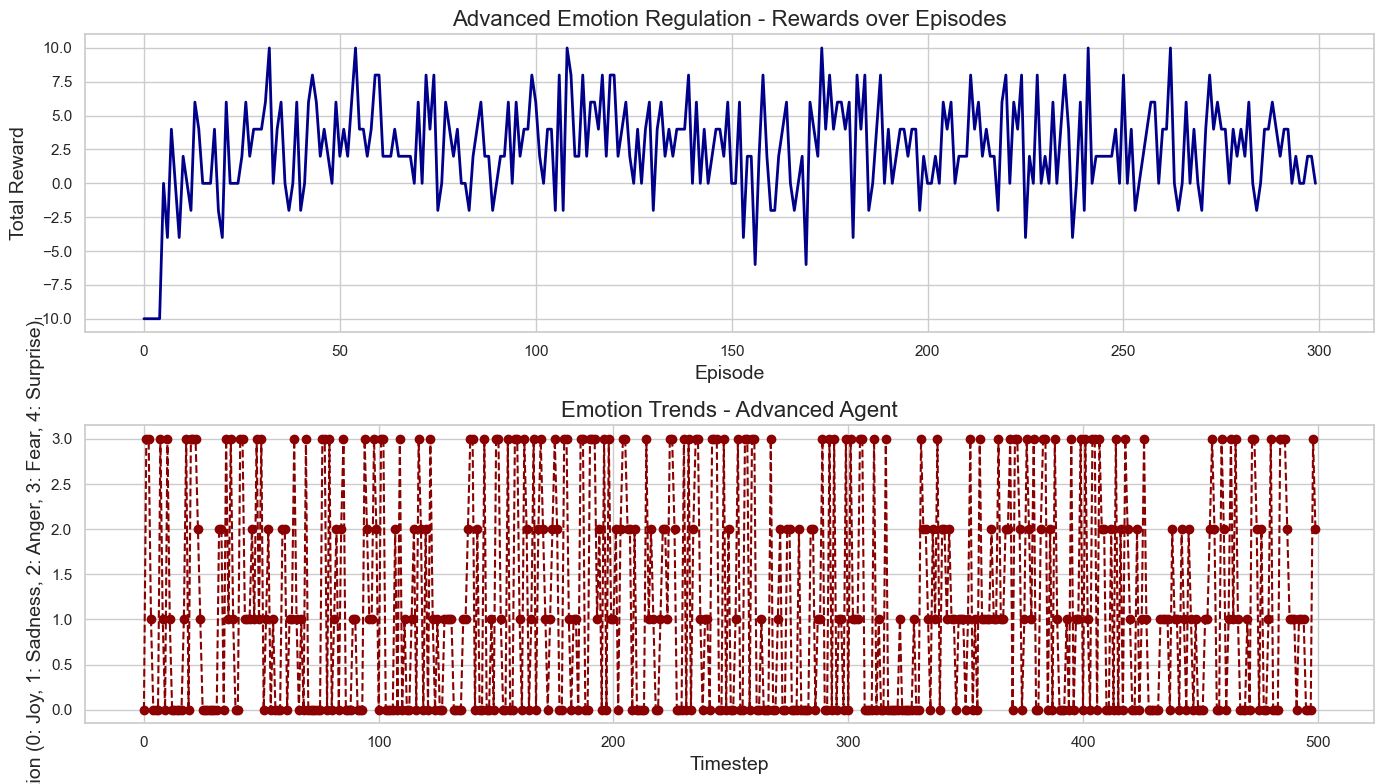

In [198]:
# Limit data to the first 500 steps (for clearer visualization and consistent size)
reward_history = reward_history[:500]
emotion_trend_advanced = emotion_trend_advanced[:500]

# Create a new figure for plotting with a specific size
plt.figure(figsize=(14, 8))

# ----------------- Plot 1: Rewards over Episodes -----------------
plt.subplot(2, 1, 1)  # First subplot (2 rows, 1 column, position 1)
plt.plot(reward_history, color='darkblue', linewidth=2)  # Plot reward history
plt.title("Advanced Emotion Regulation - Rewards over Episodes", fontsize=16)
plt.xlabel("Episode", fontsize=14)  # X-axis label
plt.ylabel("Total Reward", fontsize=14)  # Y-axis label
plt.grid(True)  # Add grid lines to the plot

# ----------------- Plot 2: Emotion Trends -----------------
plt.subplot(2, 1, 2)  # Second subplot (2 rows, 1 column, position 2)
plt.plot(emotion_trend_advanced, color='darkred', linestyle='--', marker='o')
# Plot the dominant emotion detected at each timestep

plt.title('Emotion Trends - Advanced Agent', fontsize=16)
plt.xlabel('Timestep', fontsize=14)  # X-axis label
plt.ylabel('Emotion (0: Joy, 1: Sadness, 2: Anger, 3: Fear, 4: Surprise)', fontsize=14)
plt.grid(True)  # Add grid for better readability

# Automatically adjust spacing between subplots to prevent overlap
plt.tight_layout()

# Display the final plots
plt.show()

# 4. Comparison between Basic and Advanced Agents

Finally, we compare both models' performances visually.

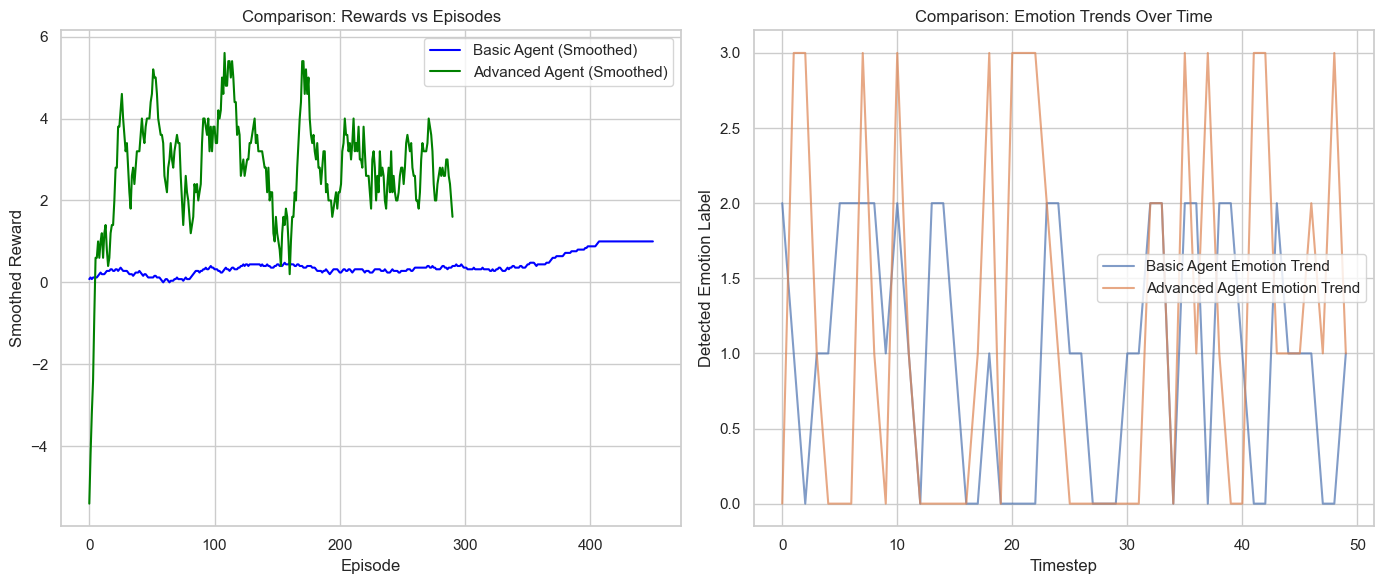

In [201]:
# Smooth the advanced agent's reward history using a moving average with a window size of 10
advanced_smoothed_rewards = np.convolve(reward_history, np.ones(10) / 10, mode='valid')

# Limit the emotion trend lists to the first 50 timesteps to ensure both trends are aligned in length
emotion_trend_basic = emotion_trend_basic[:50]
emotion_trend_advanced = emotion_trend_advanced[:50]

# Create a new figure for the comparison plots, with a larger size for better visibility
plt.figure(figsize=(14, 6))

# === Subplot 1: Compare Smoothed Reward Trends ===
plt.subplot(1, 2, 1)
# Plot basic agent's smoothed rewards over episodes
plt.plot(smoothed_rewards, label='Basic Agent (Smoothed)', color='blue')
# Plot advanced agent's smoothed rewards over episodes
plt.plot(advanced_smoothed_rewards, label='Advanced Agent (Smoothed)', color='green')
# Set title and axis labels
plt.title('Comparison: Rewards vs Episodes')
plt.xlabel('Episode')
plt.ylabel('Smoothed Reward')
# Add a legend to differentiate the agents
plt.legend()
# Enable grid for easier reading
plt.grid(True)

# === Subplot 2: Compare Emotion Trends ===
plt.subplot(1, 2, 2)
# Plot emotion label trends over time for the basic agent
plt.plot(emotion_trend_basic[:len(emotion_trend_advanced)], label='Basic Agent Emotion Trend', alpha=0.7)
# Plot emotion label trends over time for the advanced agent
plt.plot(emotion_trend_advanced, label='Advanced Agent Emotion Trend', alpha=0.7)
# Set title and axis labels
plt.title('Comparison: Emotion Trends Over Time')
plt.xlabel('Timestep')
plt.ylabel('Detected Emotion Label')
# Add a legend to identify agents
plt.legend()
# Enable grid for readability
plt.grid(True)

# Adjust layout so subplots don't overlap
plt.tight_layout()
# Display the final visualization
plt.show()


## Summary of Graphs and Functionality:

- Rewards vs Episodes: Shows the agent’s performance in terms of total rewards obtained per episode.

- Emotional Trends: Displays the dominant emotional categories predicted by the agent throughout training. This helps you see which emotions the agent is encountering most often.

- Real-Time Testing: Input a sentence, and the agent will analyze the emotion and decide on an action based on its training.

# 5. Real-Time Testing
Test the trained advanced agent on custom sentences!

In [204]:
# Define a function to test the Advanced Emotion Regulation Agent on a single sentence
def test_advanced_agent(sentence):
    # Step 1: Convert input sentence into an emotion vector using the BERT model
    state = get_emotion_vector(sentence)

    # Step 2: Convert the emotion vector to a tensor and add a batch dimension
    # (unsqueeze(0) makes it shape [1, state_dim] as required by the model)
    state_tensor = torch.FloatTensor(state).unsqueeze(0)

    # Step 3: Pass the emotion vector through the trained agent to get Q-values for each action
    q_values = advanced_agent(state_tensor)

    # Step 4: Select the action with the highest Q-value (greedy policy)
    action = torch.argmax(q_values).item()

    # Define the human-readable labels for each possible action
    actions = ['Calm Down', 'Cheer Up', 'Maintain Joy', 'Reduce Fear', 'Stay Neutral']

    # Print the sentence, detected emotion (vector), and the agent's chosen action
    print(f"\nInput Sentence: {sentence}")
    print(f"Detected Emotion Vector: {state}")
    print(f"Agent Action: {actions[action]}")

test_advanced_agent("I'm feeling extremely anxious about tomorrow.")
test_advanced_agent("I am very happy with my progress.")
test_advanced_agent("Nothing special today, it's normal.")


Input Sentence: I'm feeling extremely anxious about tomorrow.
Detected Emotion Vector: [0 0 0 1 0]
Agent Action: Cheer Up

Input Sentence: I am very happy with my progress.
Detected Emotion Vector: [1 0 0 0 0]
Agent Action: Maintain Joy

Input Sentence: Nothing special today, it's normal.
Detected Emotion Vector: [1 0 0 0 0]
Agent Action: Maintain Joy


# 4. Emotion Regulation Networks & AI Applications with Affective States

## Human-AI Interaction
### 1. Sentiment-Aware Virtual Assistants:
- AI learning tone, language, and response based on user emotions (e.g., Siri or Alexa becoming sympathetic if a user is frustrated).

- Example: Replika – a chatbot responding based on emotional analysis from users' texts.

### 2. Emotionally Intelligent Robots
- Robots and AI systems for application in interactions with humans in emotionally charged contexts, e.g., healthcare, elderly care, or therapy.

- Ex: Pepper Robot – Created to be capable of reading human emotions and responding appropriately.

## Applications in Mental Health
### 3. AI-Based Therapy and Counseling:
- Reinforcement learning is used by AI-powered apps like Woebot to learn to reply based on users' emotional state and provide therapeutic conversation and monitor emotional progress.

- AI helps therapists detect patterns in patient emotional states and adapt treatment approaches.

### 4. Emotion Recognition for Stress Management
- Tracking wearables AI devices' physiological responses (e.g., facial expression, heart rate) via reinforcement learning to help users manage stress and emotions.

- Example: Empatica Embrace – Real-time wearable emotional well-being and stress monitor with alerts.

# 5. Potential Challenges and Considerations:

- Ethical Concerns: Careful design is required for emotion-sensitive AI towards respecting emotional well-being and privacy. Risk of exploitation or misuse unless operated ethically.

- Contextuality: Identifying emotions in diverse contexts (e.g., stressful work environment vs. regular conversation) is challenging. The AI needs to be cognizant of such differences to avoid misinterpretation.

- Emotional Overload: Too much emphasis on emotions can lead to AI systems misreading delicate or subtle emotional states and responding inappropriately.

# 6. Future Research Applications:
1. AI for Personalized Mental Health:
Adaptive AI systems for individual therapy, where an AI tracks emotional well-being continuously and makes recommendations based on real-time affective states. 

2. Emotion-Aware Gaming:
Video game AI players who can perceive the player's emotional state and react to it, providing customized challenges or emotional feedback to increase immersion.

# 7. Conclusion:

Emotion regulation networks in the brain are essential for controlling emotional responses to internal and external stimuli. In AI, reinforcement learning with affective states attempts to replicate this by incorporating emotional feedback to guide decision-making.

Though AI with affective states promises better human-AI interactions and personal well-being, it remains in its infancy as far as understanding emotions and being adaptable. Developing more sophisticated emotional intelligence in AI systems is an area of future research that needs to be emphasized, allowing for deeper personalization in human interaction and mental health uses. 

# 8. References:

[1]	B. Cui, J. Wang, H. Lin, Y. Zhang, L. Yang, and B. Xu, “Emotion-Based Reinforcement Attention Network for Depression Detection on Social Media: Algorithm Development and Validation,” JMIR Med Inform, vol. 10, no. 8, Aug. 2022, doi: 10.2196/37818,.

[2]	Y. Kim and A. Choi, “Eeg-based emotion classification using long short-term memory network with attention mechanism,” Sensors (Switzerland), vol. 20, no. 23, pp. 1–22, Nov. 2020, doi: 10.3390/S20236727,.

[3]	M. Harel et al., “Distinct homotopic functional connectivity patterns of the amygdalar sub-regions as biomarkers in major depressive disorder,” J Affect Disord, vol. 365, pp. 285–292, Nov. 2024, doi: 10.1016/J.JAD.2024.08.023.

[4]	X. Xu et al., “Behavioral observation and assessment protocol for language and social-emotional development study in children aged 0-6: the Chinese baby connectome project,” BMC Psychol, vol. 12, no. 1, p. 533, Dec. 2024, doi: 10.1186/S40359-024-02031-X,.

[5]	A. Chadjikyprianou and F. Constantinidou, “A new multidimensional group intervention for cognitive and psychosocial functioning for older adults: Background, content, and process evaluation,” Front Med (Lausanne), vol. 10, 2023, doi: 10.3389/FMED.2023.1161060,.

[6]	C. J. van Lissa, “Mapping Phenomena Relevant to Adolescent Emotion Regulation: A Text-Mining Systematic Review,” Adolesc Res Rev, vol. 7, no. 1, pp. 127–139, Mar. 2022, doi: 10.1007/S40894-021-00160-7,.
